# Important to run this notebook
A `.env` file at the root of this repository that defines `PYTHONPATH=src/python` is required to have the correct module resolution.

In [10]:
from typing import Literal
import matplotlib.pyplot as plt
import polars as pl
import numpy as np
from results import Result

LEGEND = {
    "ucb": "UCB",
    "egreedy": "$\\epsilon$-greedy",
    "random": "Random",
    "ppo": "PPO",
    "dqn": "DQN",
    "bestslopefirst": "BSF",
}
LEGEND_ORDER = ["PPO", "DQN", "UCB", "$\\epsilon$-greedy", "Random", "BSF"]
COLOURS = {
    "ppo": "C0",
    "dqn": "C1",
    "egreedy": "C2",
    "random": "C3",
    "ucb": "C4",
    "bestslopefirst": "C5",
}


def compute_xmax(results: list[Result], by: Literal["time", "step"] = "time"):
    if by == "time":
        return max(r.t_max for r in results)
    elif by == "step":
        return max(r.step_max for r in results)
    else:
        raise ValueError(f"Unknown by value: {by}")


def compute_primal_gaps(results: list[Result], by: Literal["time", "step"] = "time"):
    tmax = compute_xmax(results, by=by)
    objs = [r.primal_gap_array(by=by, tmax=int(tmax) + 1) for r in results]
    return np.array(objs, dtype=np.float32)


def compute_objectives(results: list[Result], by: Literal["time", "step"] = "time"):
    tmax = compute_xmax(results, by=by)
    objs = [r.objective_array(by=by, tmax=int(tmax) + 1) for r in results]
    return np.array(objs, dtype=np.float32)


def plot_by_bandit(
    df: pl.DataFrame,
    metric: Literal["primal gap", "objective"] = "primal gap",
    auto_ylim: bool = True,
    x_axis: Literal["time", "step"] = "time",
    xmax: int | None = None,
    show_ci95: bool = True,
):
    ymin, ymax = float("inf"), float("-inf")
    if xmax is None:
        xmax = 0
    data = dict[str, tuple[np.ndarray, np.ndarray]]()
    for (name, *_), bandit in df.group_by(pl.col("bandit")):
        print(f"Processing {name} ({bandit.height} results)")
        results = [Result(**row) for row in bandit.iter_rows(named=True)]
        match metric:
            case "primal gap":
                arr = compute_primal_gaps(results, by=x_axis) * 100
            case "objective":
                arr = compute_objectives(results, by=x_axis)
            case other:
                raise ValueError(f"Unknown metric {other}")
        mean, std = arr.mean(axis=0), arr.std(axis=0)
        ci95 = 1.96 * std / len(results)**0.5
        xmax = max(xmax, len(mean))
        if auto_ylim:
            istart = int(-len(mean) // 2)
            ymin = min(ymin, (mean[istart:] - ci95[istart:]).min())
            ymax = max(ymax, (mean[istart:] + ci95[istart:]).max())
        data[name] = (mean, ci95)

    xs = np.arange(xmax)
    for name, (mean, ci95) in data.items():
        mean = np.concat([mean, np.full(xmax - len(mean), mean[-1])])
        plt.plot(xs, mean, label=LEGEND.get(name, name), color=COLOURS[name])
        if show_ci95:
            ci95 = np.concat([ci95, np.full(xmax - len(ci95), ci95[-1])])
            plt.fill_between(xs, mean - ci95, mean + ci95, alpha=0.2)
    if x_axis == "time":
        plt.xlabel("Time (s)")
    elif x_axis == "step":
        plt.xlabel("Steps")
    match metric:
        case "primal gap":
            plt.ylabel("Primal Gap (%)")
        case "objective":
            plt.ylabel("Objective")
    plt.margins(x=0.01, y=0.01)
    if auto_ylim:
        plt.ylim(ymin * 0.95, ymax * 1.05)
    handles, labels = plt.gca().get_legend_handles_labels()
    labels, handles = zip(*sorted(zip(labels, handles), key=lambda x: LEGEND_ORDER.index(x[0])))
    plt.legend(handles, labels, loc="upper right")

# CSP

In [2]:
import polars as pl

df = (
    pl.concat(
        [
            pl.read_csv("logs/ppo-csp_all-1h30/results.csv").with_columns(bandit=pl.lit("ppo")),
            pl.read_csv("logs/dqn-csp_all-1h30/results.csv").with_columns(bandit=pl.lit("dqn")),
            pl.read_csv("logs/random-csp_all-1h30/results.csv").with_columns(bandit=pl.lit("random")),
            pl.read_csv("logs/ucb-csp_all-1h30/results.csv").with_columns(bandit=pl.lit("ucb")),
            pl.read_csv("logs/egreedy-csp_all-1h30/results.csv").with_columns(bandit=pl.lit("egreedy")),
            pl.read_csv("logs/bestslopefirst-csp_all-1h30/results.csv").with_columns(bandit=pl.lit("bestslopefirst")),
        ],
        how="diagonal",
    )
    .drop("-a")
    .with_columns(instance_size=pl.col("instance").str.split("/").list.get(2))
)
df.height

4774

<Axes: xlabel='instance_size', ylabel='bestObj'>

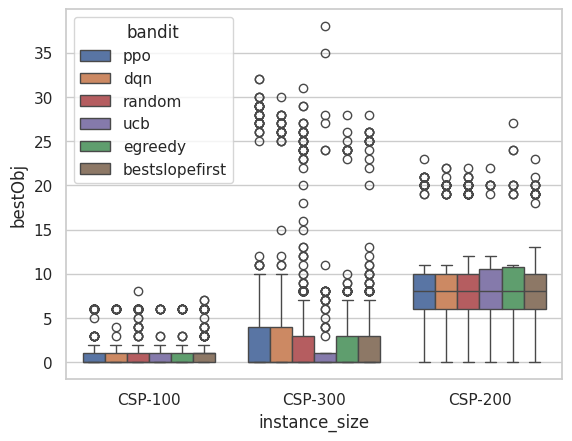

In [3]:
import seaborn as sns

sns.set_theme(style="whitegrid")

sns.boxplot(
    data=df,
    x="instance_size",
    y="bestObj",
    hue="bandit",
    palette=COLOURS,
    formatter=lambda label: LEGEND.get(label, label), # type: ignore
)

Processing dqn (840 results)
Processing ucb (293 results)
Processing ppo (1265 results)
Processing random (1260 results)
Processing bestslopefirst (696 results)
Processing egreedy (420 results)


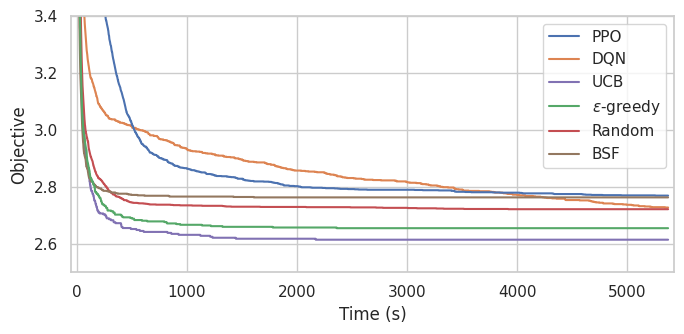

In [11]:
plt.figure(figsize=(7, 3.5))
plot_by_bandit(df, metric="objective", x_axis="time", show_ci95=False)
plt.ylim(2.5, 3.4)
#plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

Processing random (1260 results)
Processing dqn (840 results)
Processing egreedy (420 results)
Processing ppo (1265 results)
Processing ucb (293 results)
Processing bestslopefirst (696 results)


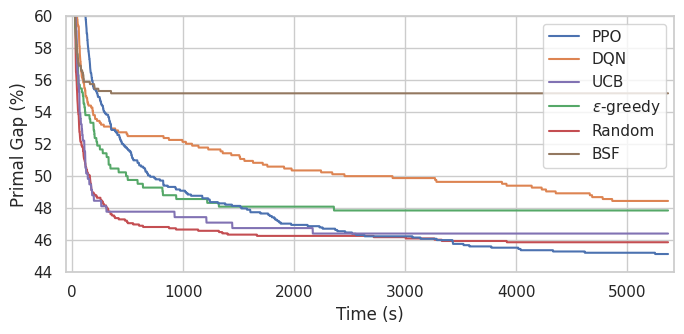

In [13]:

plt.figure(figsize=(7, 3.5))
plot_by_bandit(df, metric="primal gap", x_axis="time", show_ci95=False)
plt.ylim(44, 60)
plt.tight_layout()
plt.show()

Processing dqn (100 results)
Processing bestslopefirst (80 results)
Processing random (150 results)
Processing egreedy (50 results)
Processing ucb (35 results)
Processing ppo (150 results)


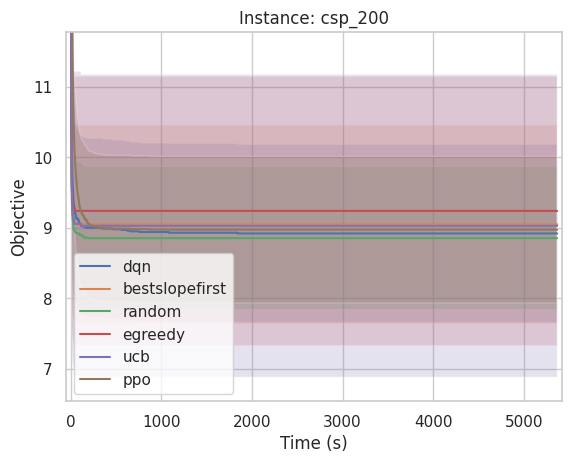

Processing random (150 results)
Processing ppo (150 results)
Processing bestslopefirst (80 results)
Processing ucb (35 results)
Processing egreedy (50 results)
Processing dqn (100 results)


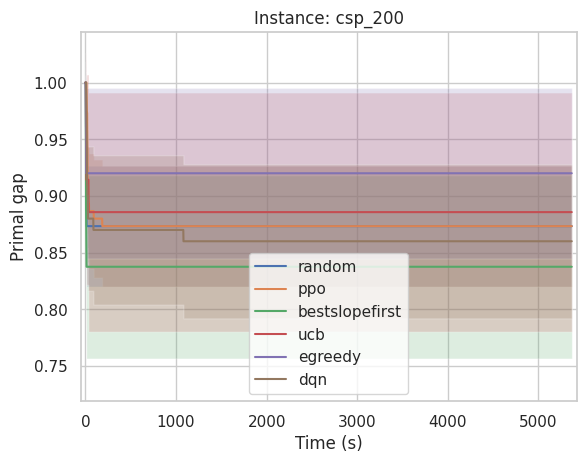

Processing ppo (480 results)
Processing ucb (110 results)
Processing random (480 results)
Processing egreedy (160 results)
Processing dqn (320 results)
Processing bestslopefirst (264 results)


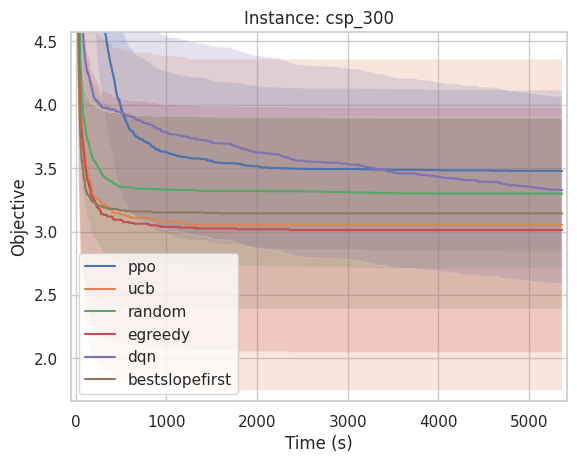

Processing random (480 results)
Processing ucb (110 results)
Processing ppo (480 results)
Processing dqn (320 results)
Processing bestslopefirst (264 results)
Processing egreedy (160 results)


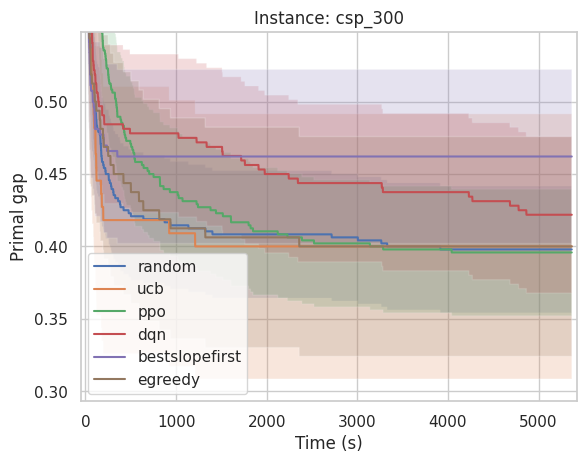

Processing dqn (420 results)
Processing ppo (635 results)
Processing random (630 results)
Processing bestslopefirst (352 results)
Processing ucb (148 results)
Processing egreedy (210 results)


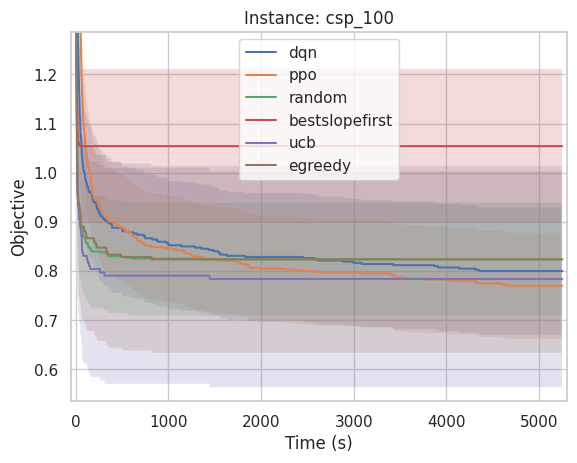

Processing ucb (148 results)
Processing random (630 results)
Processing ppo (635 results)
Processing egreedy (210 results)
Processing bestslopefirst (352 results)
Processing dqn (420 results)


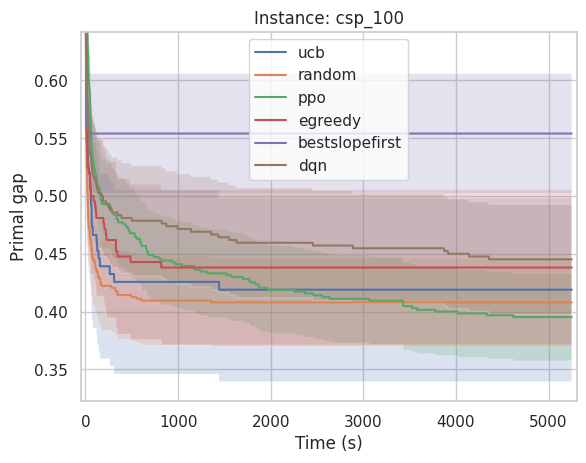

In [13]:
for (instance_size, *_) , df_instance in df.group_by("instance_size"):
    plot_by_bandit(df_instance, metric="objective", x_axis="time")
    plt.title(f"Instance: {instance_size}")
    plt.show()

    plot_by_bandit(df_instance, metric="primal gap", x_axis="time")
    plt.title(f"Instance: {instance_size}")
    plt.show()
